<a href="https://colab.research.google.com/github/sushant758/Deep-Learning/blob/main/DL_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Churn_Modelling.csv')

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [9]:
df = df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [12]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[['Geography', 'Gender']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Geography', 'Gender']),
    index=df.index
)

df = pd.concat(
    [df.drop(['Geography', 'Gender'], axis=1), encoded_df],
    axis=1
)

In [14]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0


In [15]:
X = df.drop('Exited' , axis=1)
y = df['Exited']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
print(X_train[:5])

[[ 0.35649971 -0.6557859   0.34567966 -1.21847056  0.80843615  0.64920267
   0.97481699  1.36766974  1.00150113 -0.57946723 -0.57638802 -0.91324755
   0.91324755]
 [-0.20389777  0.29493847 -0.3483691   0.69683765  0.80843615  0.64920267
   0.97481699  1.6612541  -0.99850112  1.72572313 -0.57638802 -0.91324755
   0.91324755]
 [-0.96147213 -1.41636539 -0.69539349  0.61862909 -0.91668767  0.64920267
  -1.02583358 -0.25280688 -0.99850112 -0.57946723  1.73494238 -0.91324755
   0.91324755]
 [-0.94071667 -1.13114808  1.38675281  0.95321202 -0.91668767  0.64920267
  -1.02583358  0.91539272  1.00150113 -0.57946723 -0.57638802  1.09499335
  -1.09499335]
 [-1.39733684  1.62595257  1.38675281  1.05744869 -0.91668767 -1.54035103
  -1.02583358 -1.05960019  1.00150113 -0.57946723 -0.57638802 -0.91324755
   0.91324755]]


# Artificial Neural Network

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [21]:
# Build the ANN

ANN = Sequential()

# Input layer + First Hidden Layer
ANN.add(Dense(units=6, activation = 'relu'))

# Second Hidden Layer
ANN.add(Dense(units=6, activation = 'relu'))

# Output Layer
ANN.add(Dense(units = 1 , activation = 'sigmoid'))

In [22]:
# Compile the ANN

ANN.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = ANN.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7609 - loss: 0.5731 - val_accuracy: 0.7987 - val_loss: 0.5142
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7936 - loss: 0.4890 - val_accuracy: 0.7987 - val_loss: 0.4570
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7961 - loss: 0.4556 - val_accuracy: 0.8037 - val_loss: 0.4396
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.4452 - val_accuracy: 0.8050 - val_loss: 0.4337
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7983 - loss: 0.4404 - val_accuracy: 0.8075 - val_loss: 0.4298
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7994 - loss: 0.4370 - val_accuracy: 0.8075 - val_loss: 0.4276
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8033 - loss: 0.4341 - val_accuracy: 0.8087 - val_loss: 0.4251
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8056 - loss: 0.4311 - val_accu

In [24]:
y_pred = ANN.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print(confusion_matrix(y_test, y_pred))
print()

print(classification_report(y_test, y_pred))

Accuracy: 0.857

[[1522   85]
 [ 201  192]]

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1607
           1       0.69      0.49      0.57       393

    accuracy                           0.86      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.85      0.86      0.85      2000



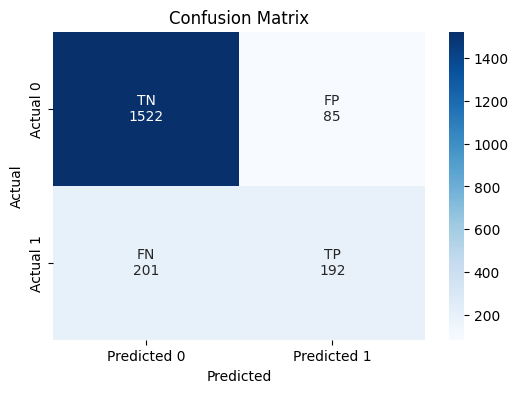

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Labels
labels = [['TN', 'FP'],
          ['FN', 'TP']]

# Combine labels with values
annot = [[f'{labels[i][j]}\n{cm[i][j]}' for j in range(2)] for i in range(2)]

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm,
            annot=annot,
            fmt='',
            cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
ANN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 6)                │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 6)                │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 1)                │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 133 (532.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 268 (1.05 KB)